# **IMPORT LIBRARIES**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# **TOPIC**

> **Nén ảnh dùng Kmeans:** Dùng Kmeans để thay thế nền trong ảnh?

# **CODE HERE**

In [2]:
# Đọc ảnh
img_game = cv2.imread('balls.png')
img_background = cv2.imread('background.jpg')

In [3]:
# Chuyển đổi không gian màu từ BGR sang RGB
img_game = cv2.cvtColor(img_game, cv2.COLOR_BGR2RGB)
img_background = cv2.cvtColor(img_background, cv2.COLOR_BGR2RGB)

In [4]:
# Lấy kích thước ảnh
height, width, channels = img_game.shape

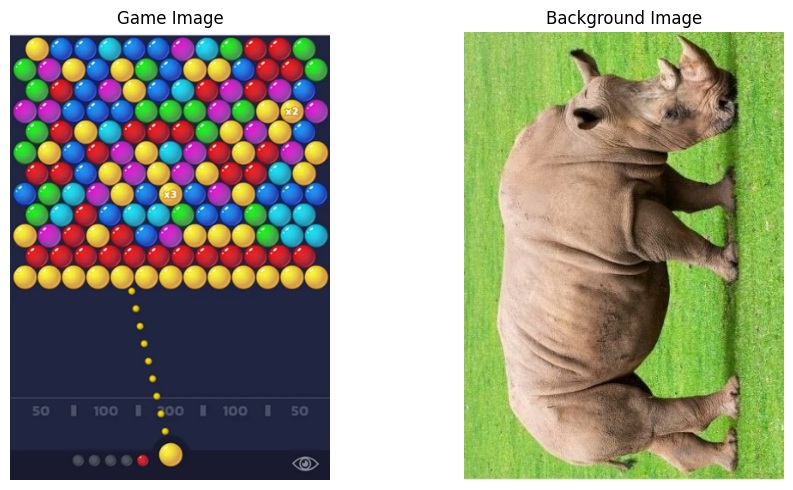

In [5]:
# Hiển thị ảnh
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_game)
plt.title('Game Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_background)
plt.title('Background Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Chuyển thành dữ liệu N x 3
pixels = img_game.reshape(-1, 3)

In [7]:
# Thực hiện K-Means
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(pixels)
labels = kmeans.fit_predict(pixels)

In [8]:
# Xác định nhãn nào là nền (Background Label) -> Nhãn nào xuất hiện nhiều là nền
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} lần")

Label 0: 25616 lần
Label 1: 109046 lần
Label 2: 21075 lần
Label 3: 29486 lần
Label 4: 9483 lần


In [9]:
# Xác định nhãn nào là nền (Background Label)
background_label = 1

In [10]:
# Tạo ảnh kết quả
mask = labels.reshape((height, width))

In [11]:
# Tạo ảnh kết quả 
img_result = img_game.copy()

# Thay thế pixel
img_result[mask == background_label] = img_background[mask == background_label]

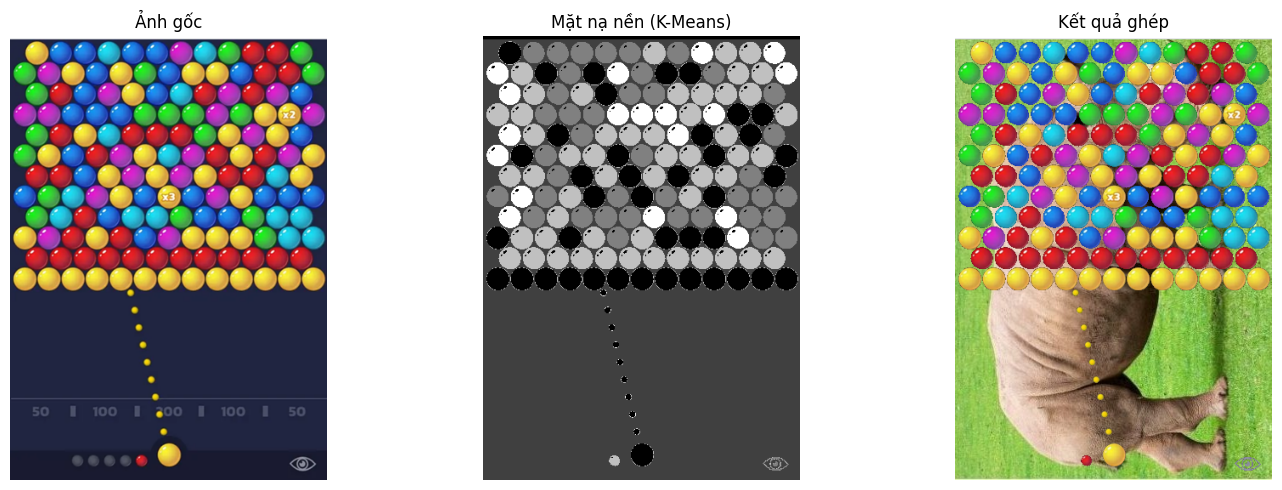

In [12]:
# Hiển thị kết quả
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Ảnh gốc")
plt.imshow(img_game)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Mặt nạ nền (K-Means)")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Kết quả ghép")
plt.imshow(img_result)
plt.axis('off')

plt.tight_layout()
plt.show()

# **CONCLUDE**

## **1. Mục tiêu đạt được**
Chúng ta đã giải quyết thành công bài toán **Phân đoạn ảnh (Image Segmentation)** ở mức cơ bản:  
- Tách đối tượng (các quả bóng) ra khỏi nền (background).  
- Thay thế nền bằng một hình ảnh khác.

## **2. Các bài học kỹ thuật cốt lõi (Key Takeaways)**

### **K-Means trong xử lý ảnh**
- Máy tính không “nhìn thấy” quả bóng hay con tê giác — nó chỉ nhìn thấy **các giá trị màu RGB**.  
- K-Means giúp **gom nhóm các pixel có màu sắc gần giống nhau** vào cùng một cụm → từ đó phân biệt nền và vật thể.

### **Vai trò của số cụm K**
- **K = 2:**  
  - Ảnh bị ép chia thành 2 nhóm màu chủ đạo.  
  - Nếu vật thể có màu gần giống nền (ví dụ: bóng xanh dương trên nền xanh tối), chúng dễ bị gộp chung → mất chi tiết.

- **K lớn hơn (ví dụ K = 5):**  
  - Thuật toán phân biệt được nhiều vùng màu hơn (xanh dương, xanh lục, xanh tối, vàng, đỏ...).  
  - Ta loại bỏ cụm nền và giữ lại các cụm vật thể.

### **Kỹ thuật Masking (Tạo mặt nạ)**
- Là kỹ thuật quan trọng nhất trong xử lý ảnh.  
- `mask` (True/False): xác định vùng được chọn để thao tác.  
- `~mask`: đảo ngược vùng chọn (từ chọn nền → chọn vật thể).  
- Ảnh nền mới và ảnh gốc **phải cùng kích thước** để ghép chính xác.

## **3. Đánh giá phương pháp**

### **Ưu điểm**
- Dễ hiểu và dễ cài đặt.  
- Hiệu quả với ảnh có **tương phản màu sắc cao** giữa vật thể và nền.  
- Là kiến thức nền tảng để hiểu về **học máy không giám sát (Unsupervised Learning)**.

### **Nhược điểm**
- **Phụ thuộc màu sắc**: Nếu vật thể có màu gần giống nền → K-Means dễ gộp nhầm và làm mất chi tiết.  
- **Xử lý biên (Edge)**: Viền thường bị răng cưa, không mượt như các phương pháp hiện đại (Photoshop, Deep Learning).  
- **Tốc độ**: Chậm khi áp dụng trên ảnh độ phân giải cao.